# Fetch POI Data

In this notebook we gather **Points-of-Interest (POI)** features for the Chicago
area from **OpenStreetMap** via the [Overpass API](https://wiki.openstreetmap.org/wiki/Overpass_API)
(free, no API key required; downloaded on 01.06.2026).

The trip data is only available at **census-tract** level (`GEOID10`) and at
**H3-hexagon** level (resolutions `low=6`, `medium=7`, `high=8`). POIs are points
in space, so we aggregate them onto these two spatial grids so the features can be
joined directly to the trip records.

We produce the following features per spatial unit:

| Feature | Type | Unit |
|---|---|---|
| `dist_to_nearest_airport_km` | distance | km |
| `dist_to_nearest_train_station_km` | distance | km |
| `dist_to_nearest_stadium_or_arena_km` | distance | km |
| `dist_to_nearest_landmark_km` | distance | km |
| `count_bars_and_clubs` / `bars_and_clubs_per_km2` | count / density | – / km⁻² |
| `count_hotels` / `hotels_per_km2` | count / density | – / km⁻² |
| `count_restaurants` / `restaurants_per_km2` | count / density | – / km⁻² |

### Choosing comparable units

The spatial units differ enormously in size (Cook County census tracts range from
~0.01 km² downtown to >1000 km² for the Lake Michigan tract), so a raw count is
**not** comparable across units. We make every feature comparable as follows:

- **Distances** are measured in **kilometres from the centroid of the unit to the
  nearest POI** of that type. A distance is independent of the unit's size, so it
  is directly comparable across tracts *and* hexagons.
- **Counts** are reported both as an **absolute count** inside the unit *and* as a
  **density (count per km²)**. Density divides out the area, making it the
  comparable measure across the variable-sized census tracts. H3 cells at a fixed
  resolution are (approximately) equal-area, so for them counts are already
  comparable — we still report density for a consistent schema.

All geometry is projected to **EPSG:26971 (NAD83 / Illinois East, metres)** before
any distance or area is computed, so the kilometre and km² values are metric and
accurate for the Chicago region.

In [1]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import os
import time

import numpy as np
import pandas as pd
import geopandas as gpd
import h3
from shapely.geometry import Point, Polygon

import requests
import requests_cache

import matplotlib.pyplot as plt

In [2]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Configuration                           #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

TRACT_SHP  = "../../data/tl_2010_17031_tract10/tl_2010_17031_tract10.shp"
TRACT_COL  = "GEOID10"
OUT_DIR    = "../../data/poi"

# Metric CRS for the Chicago region (NAD83 / Illinois East, units = metres)
METRIC_CRS = 26971

# H3 resolutions, matching the trip data (pickup/dropoff_h3_low/medium/high)
RESOLUTIONS = {"low": 6, "medium": 7, "high": 8}

# Public Overpass mirrors, tried in order with retries (the main instance is
# sometimes overloaded, so we fall back to community mirrors).
OVERPASS_ENDPOINTS = [
    "https://overpass.kumi.systems/api/interpreter",
    "https://overpass.private.coffee/api/interpreter",
    "https://overpass-api.de/api/interpreter",
]
HTTP_HEADERS = {
    "User-Agent": "AAA-taxi-research/1.0 (academic project; POI feature fetch)",
    "Content-Type": "text/plain",
}

# POI categories. Each is a set of OpenStreetMap tag selectors queried over
# node/way/relation. "kind" controls the feature type:
#   distance -> distance from unit centroid to nearest POI (km)
#   count    -> POIs inside the unit (absolute count + density per km2)
CATEGORIES = {
    "airport": {
        "kind": "distance",
        # only aerodromes with an IATA code => real commercial airports
        # (O'Hare/ORD, Midway/MDW, Gary/GYY, ...), not private airstrips
        "filters": ['["aeroway"="aerodrome"]["iata"]'],
    },
    "train_station": {
        "kind": "distance",
        "filters": ['["railway"="station"]'],  # Metra, CTA 'L', Amtrak
    },
    "stadium_or_arena": {
        "kind": "distance",
        "filters": ['["leisure"="stadium"]', '["building"="stadium"]'],
    },
    "landmark": {
        "kind": "distance",
        "filters": [
            '["tourism"="attraction"]',
            '["historic"="monument"]',
            '["historic"="memorial"]',
        ],
    },
    "bars_and_clubs": {
        "kind": "count",
        "filters": [
            '["amenity"="bar"]',
            '["amenity"="pub"]',
            '["amenity"="nightclub"]',
        ],
    },
    "hotels": {
        "kind": "count",
        "filters": ['["tourism"="hotel"]'],
    },
    "restaurants": {
        "kind": "count",
        "filters": ['["amenity"="restaurant"]'],
    },
}

os.makedirs(OUT_DIR, exist_ok=True)

# Cache Overpass responses so re-runs are instant and we stay polite to the API.
session = requests_cache.CachedSession(
    os.path.join(OUT_DIR, ".overpass_cache"),
    allowable_methods=["GET", "POST"],
    allowable_codes=[200],
    expire_after=-1,
)

## 1. Load census tracts & define the query area

We load the official 2010 Cook County census-tract polygons. Their bounding box
(padded a little so that POIs just outside the city are still found for edge
units) defines the area we query OpenStreetMap for.

In [3]:
tracts = gpd.read_file(TRACT_SHP).to_crs(4326)
tracts[TRACT_COL] = tracts[TRACT_COL].astype(str)

# Overpass expects the bbox as "south,west,north,east"; pad by ~0.15 deg (~15 km)
west, south, east, north = tracts.total_bounds
PAD = 0.15
BBOX = f"{south - PAD},{west - PAD},{north + PAD},{east + PAD}"

print(f"Census tracts: {len(tracts):,}")
print(f"Query bbox (S,W,N,E): {BBOX}")
tracts[[TRACT_COL, "NAMELSAD10", "geometry"]].head()

Census tracts: 1,319
Query bbox (S,W,N,E): 41.319524,-88.413507,42.304292,-86.96116199999999


,GEOID10,NAMELSAD10,geometry
0,17031840300,Census Tract 8403,"POLYGON ((-87.68608 41.82296, -87.68607 41.823..."
1,17031840200,Census Tract 8402,"POLYGON ((-87.64633 41.84009, -87.64632 41.839..."
2,17031841100,Census Tract 8411,"POLYGON ((-87.62935 41.8528, -87.62934 41.8525..."
3,17031841200,Census Tract 8412,"POLYGON ((-87.68814 41.85569, -87.68816 41.856..."
4,17031838200,Census Tract 8382,"POLYGON ((-87.66782 41.87418, -87.66768 41.874..."


## 2. Fetch POIs from OpenStreetMap

For each category we build one Overpass QL query that unions all its tag
selectors across nodes, ways and relations. `out center;` returns a single
representative coordinate for ways/relations (their centroid), so every POI
becomes a point we can map onto the spatial grids.

In [4]:
def build_overpass_query(filters, bbox):
    """Union all tag selectors over node/way/relation within the bbox."""
    body = "\n".join(
        f"  {element}{flt}({bbox});"
        for flt in filters
        for element in ("node", "way", "relation")
    )
    return f"[out:json][timeout:180];\n(\n{body}\n);\nout center;"


def fetch_overpass(filters, bbox, retries=6):
    """Run a query against the Overpass mirrors with retries + caching."""
    query = build_overpass_query(filters, bbox)
    last_error = None
    for attempt in range(retries):
        endpoint = OVERPASS_ENDPOINTS[attempt % len(OVERPASS_ENDPOINTS)]
        try:
            resp = session.post(
                endpoint, data=query.encode("utf-8"),
                headers=HTTP_HEADERS, timeout=300,
            )
            if resp.status_code == 200:
                return resp.json()["elements"]
            last_error = f"{endpoint} -> HTTP {resp.status_code}"
        except Exception as exc:  # network / decode errors -> retry next mirror
            last_error = f"{endpoint} -> {type(exc).__name__}"
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"Overpass failed after {retries} attempts: {last_error}")


def elements_to_points(elements):
    """Convert Overpass elements to a GeoDataFrame of points (EPSG:4326)."""
    points = []
    for el in elements:
        if el["type"] == "node":
            lon, lat = el["lon"], el["lat"]
        else:  # way / relation -> use the 'center' from `out center;`
            center = el.get("center")
            if not center:
                continue
            lon, lat = center["lon"], center["lat"]
        points.append(Point(lon, lat))
    return gpd.GeoDataFrame(geometry=points, crs=4326)

In [5]:
# Fetch every category once (cached). Cells over water / far suburbs are fine —
# distance features only care about the nearest POI, counts only about POIs
# inside the unit.
poi_layers = {}
for name, cfg in CATEGORIES.items():
    elements = fetch_overpass(cfg["filters"], BBOX)
    poi_layers[name] = elements_to_points(elements)
    print(f"{name:18s} {cfg['kind']:8s} -> {len(poi_layers[name]):5,d} POIs")
    time.sleep(1)  # be polite between queries

airport            distance ->     8 POIs


train_station      distance ->   363 POIs


stadium_or_arena   distance ->   101 POIs


landmark           distance -> 1,065 POIs


bars_and_clubs     count    -> 1,355 POIs


hotels             count    ->   636 POIs


restaurants        count    -> 5,284 POIs


## 3. Feature engineering

A single function computes all features for any layer of spatial units (census
tracts *or* H3 hexagons), so both grids are treated identically:

- **distance** categories → project to metres, take each unit's centroid, find the
  nearest POI with `sjoin_nearest`, report the distance in **km**.
- **count** categories → spatial-join POIs that fall *within* each unit, report the
  **absolute count** and the **density (count / area in km²)**.

In [6]:
def compute_poi_features(units, id_col, poi_layers):
    """Compute all POI features for a layer of spatial units keyed by `id_col`."""
    units_m = units.to_crs(METRIC_CRS).copy()
    units_m["area_km2"] = units_m.geometry.area / 1e6

    centroids = units_m.copy()
    centroids["geometry"] = units_m.geometry.centroid

    feats = units_m[[id_col, "area_km2"]].reset_index(drop=True).copy()

    for name, cfg in CATEGORIES.items():
        poi = poi_layers.get(name)

        if cfg["kind"] == "distance":
            col = f"dist_to_nearest_{name}_km"
            if poi is None or poi.empty:
                feats[col] = np.nan
                continue
            nearest = gpd.sjoin_nearest(
                centroids[[id_col, "geometry"]],
                poi.to_crs(METRIC_CRS)[["geometry"]],
                how="left", distance_col="_dist_m",
            )
            # sjoin_nearest can return ties (>1 row per unit) -> keep the minimum
            dist_km = nearest.groupby(id_col)["_dist_m"].min() / 1000.0
            feats[col] = feats[id_col].map(dist_km)

        else:  # count
            count_col = f"count_{name}"
            density_col = f"{name}_per_km2"
            if poi is None or poi.empty:
                feats[count_col] = 0
                feats[density_col] = 0.0
                continue
            inside = gpd.sjoin(
                poi.to_crs(METRIC_CRS)[["geometry"]],
                units_m[[id_col, "geometry"]],
                predicate="within",
            )
            counts = inside.groupby(id_col).size()
            feats[count_col] = feats[id_col].map(counts).fillna(0).astype(int)
            feats[density_col] = feats[count_col] / feats["area_km2"]

    return feats

## 4. Census-tract-level features

Keyed by `GEOID10`, ready to join onto `pickup_census_tract` / `dropoff_census_tract`.

In [7]:
tract_features = compute_poi_features(tracts, TRACT_COL, poi_layers)

tract_path = os.path.join(OUT_DIR, "poi_features_census_tract.csv")
tract_features.to_csv(tract_path, index=False)
print(f"Saved {len(tract_features):,} tracts -> {tract_path}")

tract_features.describe().round(2)

Saved 1,319 tracts -> ../../data/poi/poi_features_census_tract.csv


,area_km2,dist_to_nearest_airport_km,dist_to_nearest_train_station_km,dist_to_nearest_stadium_or_arena_km,dist_to_nearest_landmark_km,count_bars_and_clubs,bars_and_clubs_per_km2,count_hotels,hotels_per_km2,count_restaurants,restaurants_per_km2
count,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00
mean,3.21,12.63,1.52,3.98,1.32,0.85,1.89,0.27,0.37,2.72,4.83
std,47.37,5.12,1.37,3.22,1.11,2.23,6.31,1.49,3.23,6.30,13.79
min,0.01,0.11,0.04,0.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,9.00,0.59,1.79,0.60,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.96,12.48,1.14,3.05,1.06,0.00,0.00,0.00,0.00,1.00,0.52
75%,2.17,16.07,2.02,5.03,1.71,1.00,0.67,0.00,0.00,3.00,3.05
max,1717.25,35.89,20.75,21.36,18.81,26.00,105.41,24.00,57.54,93.00,210.83


## 5. H3-hexagon-level features (low / medium / high)

We tile the census-tract footprint with H3 cells at each resolution and compute
the same features per hexagon. The three resolutions are stacked into one table
with a `resolution` column, keyed by `h3_cell` — ready to join onto the
`pickup_h3_*` / `dropoff_h3_*` columns of the trip data.

In [8]:
def build_h3_layer(area_gdf, resolution):
    """Cover the footprint of `area_gdf` with H3 cells at the given resolution."""
    footprint = area_gdf.to_crs(4326).union_all()
    parts = footprint.geoms if footprint.geom_type == "MultiPolygon" else [footprint]

    cells = set()
    for part in parts:
        # h3.geo_to_cells takes a single Polygon's GeoJSON mapping
        cells.update(h3.geo_to_cells(part.__geo_interface__, resolution))
    cells = sorted(cells)

    # h3.cell_to_boundary returns (lat, lon) pairs -> flip to (lon, lat) for shapely
    polygons = [
        Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
        for cell in cells
    ]
    return gpd.GeoDataFrame({"h3_cell": cells, "geometry": polygons}, crs=4326)

In [9]:
h3_frames = []
for res_name, res_level in RESOLUTIONS.items():
    hex_layer = build_h3_layer(tracts, res_level)
    hex_features = compute_poi_features(hex_layer, "h3_cell", poi_layers)
    hex_features.insert(0, "resolution", res_name)
    hex_features.insert(1, "h3_res", res_level)
    h3_frames.append(hex_features)
    print(f"{res_name:6s} (res {res_level}): {len(hex_features):5,d} hexagons")

h3_features = pd.concat(h3_frames, ignore_index=True)

h3_path = os.path.join(OUT_DIR, "poi_features_h3.csv")
h3_features.to_csv(h3_path, index=False)
print(f"\nSaved {len(h3_features):,} hexagon rows -> {h3_path}")
h3_features.head()

low    (res 6):   115 hexagons


medium (res 7):   809 hexagons


high   (res 8): 5,689 hexagons

Saved 6,613 hexagon rows -> ../../data/poi/poi_features_h3.csv


,resolution,h3_res,h3_cell,area_km2,dist_to_nearest_airport_km,dist_to_nearest_train_station_km,dist_to_nearest_stadium_or_arena_km,dist_to_nearest_landmark_km,count_bars_and_clubs,bars_and_clubs_per_km2,count_hotels,hotels_per_km2,count_restaurants,restaurants_per_km2
0,low,6,862664087ffffff,36.268357,14.250512,1.392309,8.285097,1.687439,1,0.027572,3,0.082717,8,0.220578
1,low,6,862664097ffffff,36.261885,19.107259,5.531044,13.810703,2.023614,0,0.000000,0,0.000000,2,0.055154
2,low,6,86266409fffffff,36.231374,20.540419,6.379659,9.060402,4.829980,0,0.000000,0,0.000000,0,0.000000
3,low,6,8626640b7ffffff,36.298841,13.523744,4.034520,11.326023,2.142395,0,0.000000,7,0.192844,11,0.303040
4,low,6,862664197ffffff,36.366158,13.417425,3.463863,5.190882,1.278315,8,0.219985,0,0.000000,15,0.412471


## 6. Sanity-check maps — census tracts

A few choropleths to confirm the features look spatially sensible: distances grow
smoothly away from the airports and the downtown landmark cluster, while
restaurant / bar density peaks in the Loop and on the North Side.

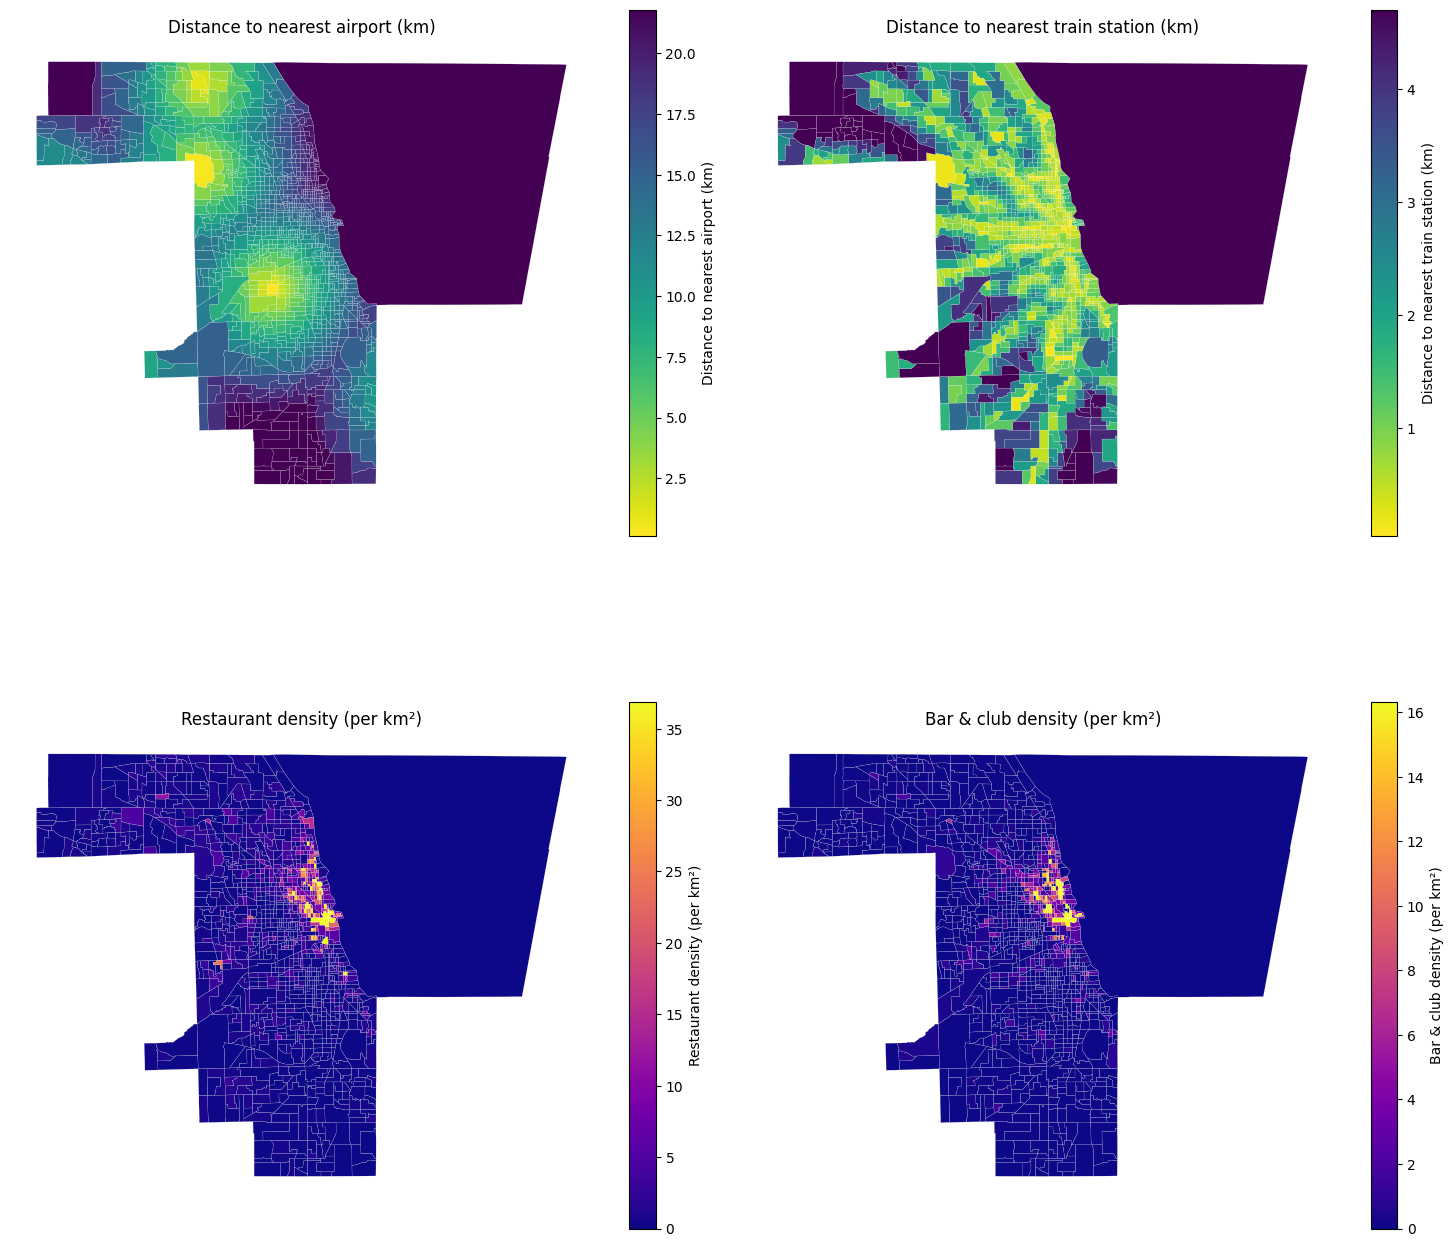

In [10]:
plot_gdf = tracts.merge(tract_features, on=TRACT_COL)

panels = [
    ("dist_to_nearest_airport_km",      "Distance to nearest airport (km)",  "viridis_r"),
    ("dist_to_nearest_train_station_km","Distance to nearest train station (km)", "viridis_r"),
    ("restaurants_per_km2",             "Restaurant density (per km²)",      "plasma"),
    ("bars_and_clubs_per_km2",          "Bar & club density (per km²)",      "plasma"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 16))
for ax, (col, title, cmap) in zip(axes.ravel(), panels):
    # cap the colour scale at the 97th pct so a few extremes don't wash out the map
    vmax = plot_gdf[col].quantile(0.97)
    plot_gdf.plot(
        column=col, cmap=cmap, vmax=vmax, legend=True,
        legend_kwds={"label": title, "shrink": 0.6},
        edgecolor="white", linewidth=0.1, ax=ax,
    )
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## 7. Sanity-check maps — H3 hexagons

The same four features on the H3 grid. We rebuild the hexagon geometry from the
`h3_cell` ids, draw the census-tract outlines underneath for orientation, and
default to the **medium** resolution (res 7) — change `H3_RES_TO_PLOT` to
`"low"` or `"high"` to compare.

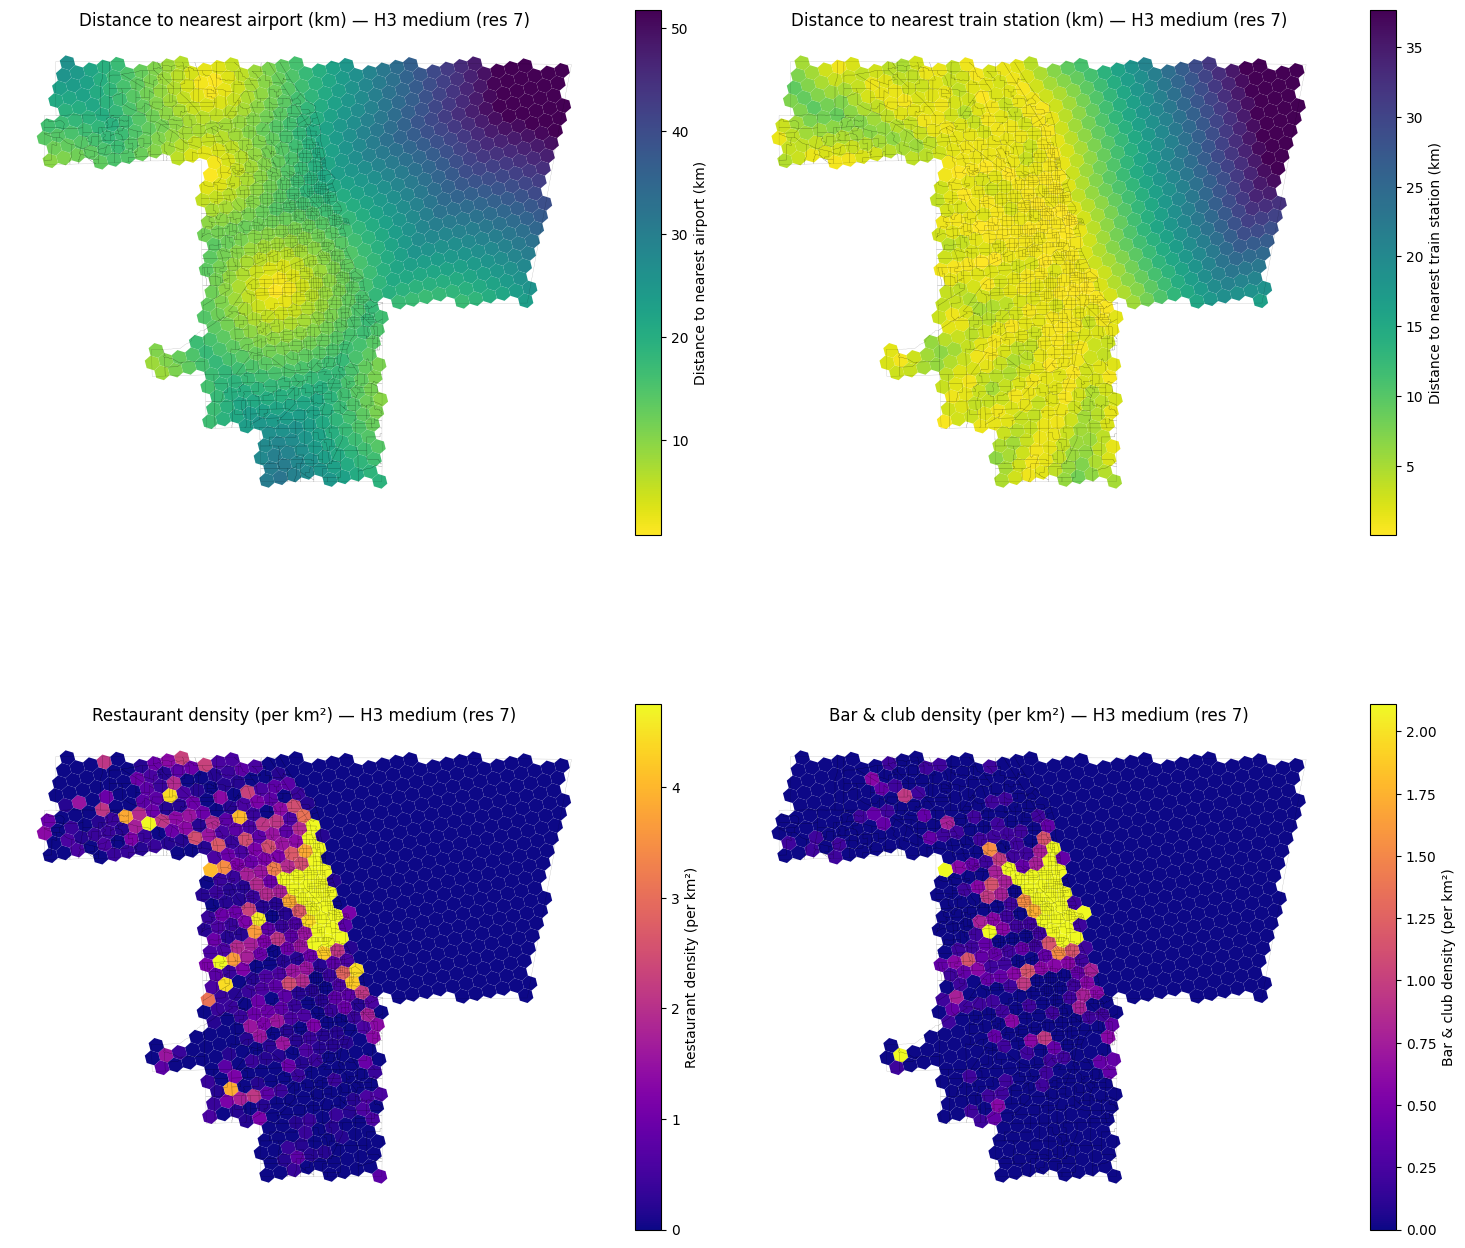

In [11]:
# Four-feature H3 choropleths at one resolution (mirrors the census-tract maps).
H3_RES_TO_PLOT = "medium"  # "low" | "medium" | "high"

panels = [
    ("dist_to_nearest_airport_km",       "Distance to nearest airport (km)",       "viridis_r"),
    ("dist_to_nearest_train_station_km", "Distance to nearest train station (km)", "viridis_r"),
    ("restaurants_per_km2",              "Restaurant density (per km²)",           "plasma"),
    ("bars_and_clubs_per_km2",           "Bar & club density (per km²)",           "plasma"),
]

def h3_features_to_gdf(res_name):
    """Attach hexagon polygons to the stored H3 features for one resolution."""
    sub = h3_features[h3_features["resolution"] == res_name].copy()
    sub["geometry"] = [
        Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
        for cell in sub["h3_cell"]
    ]
    return gpd.GeoDataFrame(sub, geometry="geometry", crs=4326)

hex_gdf = h3_features_to_gdf(H3_RES_TO_PLOT)

fig, axes = plt.subplots(2, 2, figsize=(15, 16))
for ax, (col, title, cmap) in zip(axes.ravel(), panels):
    vmax = hex_gdf[col].quantile(0.97)  # cap extremes so the map isn't washed out
    tracts.boundary.plot(ax=ax, color="black", linewidth=0.2, alpha=0.3)
    hex_gdf.plot(
        column=col, cmap=cmap, vmax=vmax, legend=True,
        legend_kwds={"label": title, "shrink": 0.6}, edgecolor="none", ax=ax,
    )
    ax.set_title(f"{title} — H3 {H3_RES_TO_PLOT} (res {RESOLUTIONS[H3_RES_TO_PLOT]})")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

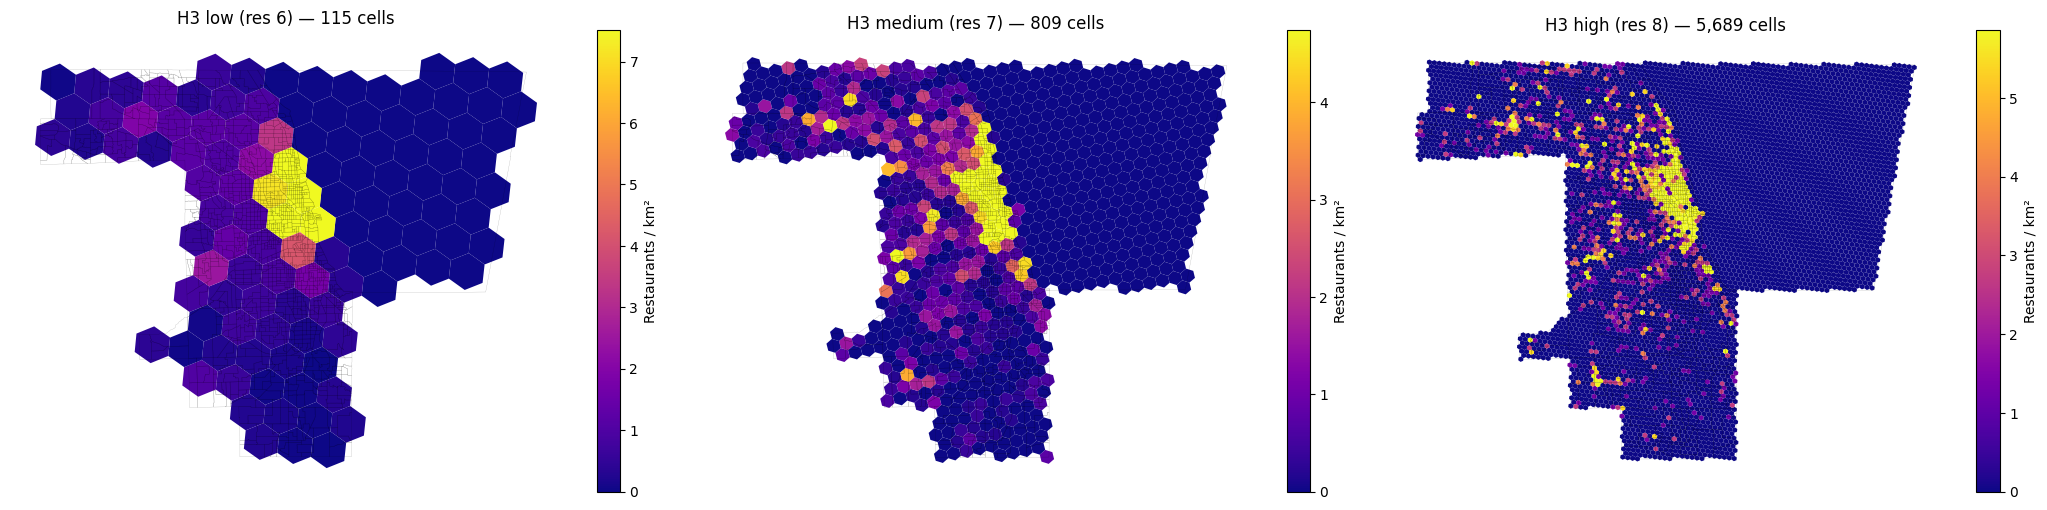

In [12]:
# How the same signal sharpens with resolution: restaurant density at low/medium/high.
fig, axes = plt.subplots(1, 3, figsize=(21, 8))
for ax, (res_name, res_level) in zip(axes, RESOLUTIONS.items()):
    g = h3_features_to_gdf(res_name)
    vmax = g["restaurants_per_km2"].quantile(0.97)
    tracts.boundary.plot(ax=ax, color="black", linewidth=0.2, alpha=0.3)
    g.plot(
        column="restaurants_per_km2", cmap="plasma", vmax=vmax, legend=True,
        legend_kwds={"label": "Restaurants / km²", "shrink": 0.6}, edgecolor="none", ax=ax,
    )
    ax.set_title(f"H3 {res_name} (res {res_level}) — {len(g):,} cells")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Outputs

| File | Key | Rows |
|---|---|---|
| `data/poi/poi_features_census_tract.csv` | `GEOID10` | one per census tract |
| `data/poi/poi_features_h3.csv` | `resolution` + `h3_cell` | one per hexagon × 3 resolutions |

**Join recipe** — distances are already comparable; for counts prefer the
`*_per_km2` density columns when comparing units of different size:

```python
poi = pd.read_csv("../../data/poi/poi_features_census_tract.csv")
poi["GEOID10"] = poi["GEOID10"].astype(str)
trips = trips.merge(
    poi.add_prefix("pickup_"),
    left_on="pickup_census_tract", right_on="pickup_GEOID10", how="left",
)
```

> **Caveat:** densities use the *full* tract/hexagon area, including water. The
> Lake Michigan tract is huge with ~0 POIs, so its density is ~0 — harmless, but
> worth remembering if you analyse waterfront units.